In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_dilated_convolutions_experimental import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

train_rows = df[df['set'] == 'train']
val_rows = df[df['set'] == 'val']
test_rows = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.7).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
#CNN.reset_weights()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
#CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)


Antal utan m-komponent i träningsdatan: 17903
Antal med m-komponent i träningsdatan: 2553


In [5]:
con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()


k_fold_rows = df[df['set'].isin(['train','val']) ].copy()
k_fold_rows = k_fold_rows[k_fold_rows['label'].isin([0,1])]
drop_indices = k_fold_rows[k_fold_rows['label'] == 0].sample(frac=0.7).index
k_fold_rows = k_fold_rows.drop(drop_indices)
print(f"Totalt antal utan m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 0])}")
print(f"Totalt antal med m-komponent i K-fold poolen: {len(k_fold_rows[k_fold_rows['label'] == 1])}")

test_rows  = df[df['set'] == 'test']


CNN = CNNModel()
CNN.retrain_with_k_fold(k_fold_rows)

Totalt antal utan m-komponent i K-fold poolen: 18848
Totalt antal med m-komponent i K-fold poolen: 2692
--- Startar 10-Fold Cross Validation ---

 FOLD 1/10
  -> ny bästa modell sparad till ../models/convolution_dilated_version_experimental_fold1.pth
Epoch   0 | train: 0.7382 | val: 0.6821 | acc: 87.59% | AUC: 0.679  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_experimental_fold1.pth
Epoch   1 | train: 0.6319 | val: 0.5964 | acc: 83.36% | AUC: 0.773  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_experimental_fold1.pth
Epoch   2 | train: 0.5127 | val: 0.5167 | acc: 71.00% | AUC: 0.826  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_experimental_fold1.pth
Epoch   3 | train: 0.4568 | val: 0.4972 | acc: 73.65% | AUC: 0.841  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version_experimental_fold1.pth
Epoch   4 | train: 0.4447 | val: 0.4744 | acc: 77.32%

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.067420,0.121730,98.094796,0.994368,0.988842,0.925926,1861,21,20,250
1,2,0.068886,0.077420,97.818013,0.995370,0.983015,0.944444,1852,32,15,255
2,3,0.077235,0.131362,97.677659,0.990037,0.985138,0.918216,1856,28,22,247
3,4,0.125677,0.174880,97.539461,0.988524,0.988329,0.884758,1863,22,31,238
4,5,0.056500,0.116270,96.332405,0.992914,0.964456,0.955390,1818,67,12,257
5,6,0.088539,0.095473,96.146704,0.995105,0.959682,0.973978,1809,76,7,262
6,7,0.079137,0.092390,97.677659,0.994029,0.980361,0.951673,1847,37,13,256
7,8,0.082987,0.163930,95.912680,0.984217,0.960722,0.947955,1810,74,14,255
8,9,0.091408,0.165119,97.491872,0.984493,0.983015,0.918216,1852,32,22,247
9,10,0.104860,0.117669,98.467255,0.993497,0.995223,0.910781,1875,9,24,245


              precision    recall  f1-score   support

     Negativ       1.00      0.99      0.99      3151
     Positiv       0.79      0.98      0.87       139

    accuracy                           0.99      3290
   macro avg       0.89      0.98      0.93      3290
weighted avg       0.99      0.99      0.99      3290

[[3115   36]
 [   3  136]]


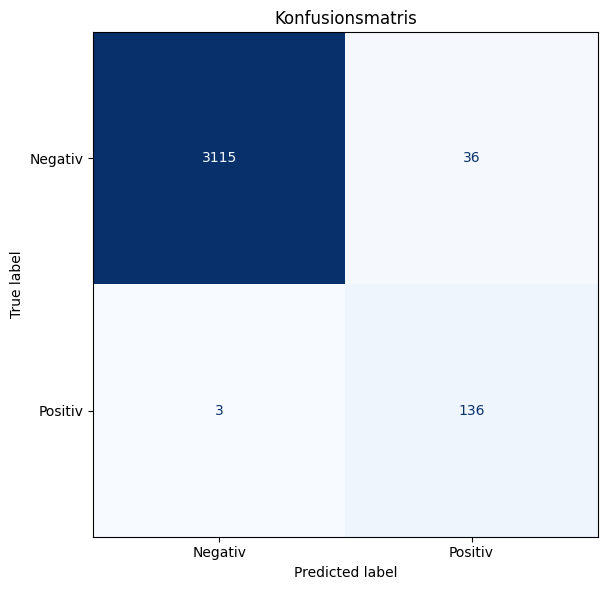

AUC: 0.9983675389107945
Accuracy:  98.81%
FN-rate:   2.16%  (farliga missade fall)
FP-rate:   1.14%  (onödiga larm)
Sensitivitet:   97.84%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   98.86%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9984


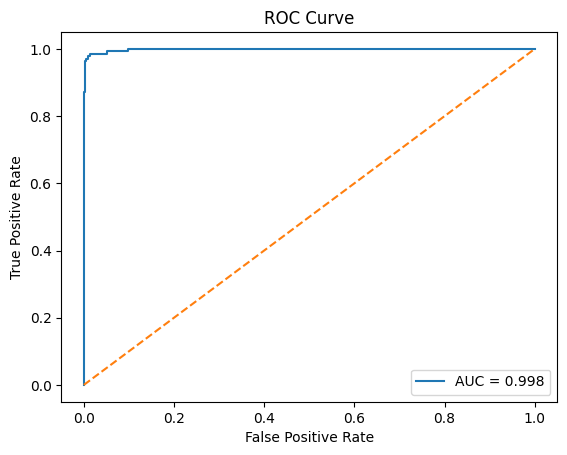

In [4]:
val_rows = val_rows[val_rows['label'].isin([0,1])]
result = CNN.predict(val_rows,threshold=0.6)
_ = evaluate(result)

In [ ]:
import pandas as pd
df = pd.read_csv('../models/kfold_metrics.csv')
df

,fold,train_loss,val_loss,val_accuracy,val_auc,val_spec,val_sens,tn,fp,fn,tp
0,1,0.129538,0.257950,95.076637,0.968738,0.963887,0.859259,1815,68,38,232
1,2,0.154077,0.200881,95.636026,0.973038,0.971338,0.851852,1830,54,40,230
2,3,0.138266,0.218713,95.403900,0.965008,0.970292,0.840149,1829,56,43,226
3,4,0.143482,0.236672,95.726893,0.968984,0.972399,0.851301,1832,52,40,229
4,5,0.198901,0.249073,93.543892,0.959826,0.949575,0.836431,1789,95,44,225
5,6,0.135832,0.187881,95.726893,0.967791,0.968684,0.877323,1825,59,33,236
6,7,0.161182,0.210965,95.450325,0.961100,0.971353,0.836431,1831,54,44,225
7,8,0.157283,0.271179,95.353160,0.963015,0.975571,0.799257,1837,46,54,215
8,9,0.196945,0.290779,95.403900,0.956873,0.970292,0.840149,1829,56,43,226
9,10,0.131366,0.179935,96.144914,0.972527,0.974522,0.869888,1836,48,35,234
